<a href="https://colab.research.google.com/github/matt-ritton/ts.ethanol-production/blob/main/ethanol-production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💻 About this notebook

This academic-oriented notebook was created to analyze historical series of sugarcane production in Brazilian states. The objective is to propose and justify a suitable model for sugarcane production forecasts.

The data were obtained from the SIDRA system of the Brazilian Institute of Geography and Statistics (IBGE).

Data: https://sidra.ibge.gov.br/tabela/6588

### 💬 What will be discussed here?
The notebook is divided into sections based on a time series analysis to solve a production prediction problem. I tried to make it as didactic as possible for understanding.

In [ ]:
# Necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
import warnings

In [ ]:
# Dataset
!wget https://raw.githubusercontent.com/matt-ritton/ts.sugarcane-production/refs/heads/main/SUGARCANE.csv

--2026-05-30 04:23:01--  https://raw.githubusercontent.com/matt-ritton/ts.sugarcane-production/refs/heads/main/SUGARCANE.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 65936 (64K) [text/plain]
Saving to: ‘SUGARCANE.csv’

SUGARCANE.csv       100%[===================>]  64.39K  --.-KB/s    in 0.001s  

2026-05-30 04:23:02 (45.9 MB/s) - ‘SUGARCANE.csv’ saved [65936/65936]



In [ ]:
# Seaborn theme
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

In [81]:
# Plotting Customs
title_style = {
    "fontweight": "semibold",
    "pad": 12
}

label_style = {
    "fontsize": 10,
    "fontweight": "semibold",
    "labelpad": 12,
}

tick_style = {
    "labelsize": 9,
    "labelcolor": "#606060"
}

grid_style = {
    "linestyle": "-",
    "linewidth": 0.7,
    "alpha": 0.35
}

In [25]:
# ------------------------------------------------------------
# Data preparation
# ------------------------------------------------------------

df = pd.read_csv('ETHANOL.csv', parse_dates=['Date'])

# Set the date as the dataset index
df = df.set_index('Date').sort_index()
df.index.freq = 'MS'

serie = df['Production'].astype(float)

# 🔍 Exploratory Time Series Analysis

Lorem Ipsum

In [26]:
# ------------------------------------------------------------
# Time Series Info
# ------------------------------------------------------------

print(f"Minas Gerais Ethanol Production")
print(f"Initial date: {serie.index.min().strftime('%Y-%m')}")
print(f"Final date: {serie.index.max().strftime('%Y-%m')}")
print(f"Number of observations: {serie.shape[0]}")
print(f"Number of missing values: {serie.isna().sum()}")

Minas Gerais Ethanol Production
Initial date: 2012-01
Final date: 2026-04
Number of observations: 172
Number of missing values: 0


In [27]:
# ------------------------------------------------------------
# Descriptive Statistics
# ------------------------------------------------------------

summary_statistics = pd.DataFrame({
    "Mean": [serie.mean()],
    "Median": [serie.median()],
    "Standard deviation": [serie.std()],
    "Minimum": [serie.min()],
    "Maximum": [serie.max()],
    "Missing values": [serie.isna().sum()]
})

summary_statistics

,Mean,Median,Standard deviation,Minimum,Maximum,Missing values
0,242171.302326,251644.0,188827.74374,0.0,574332.0,0


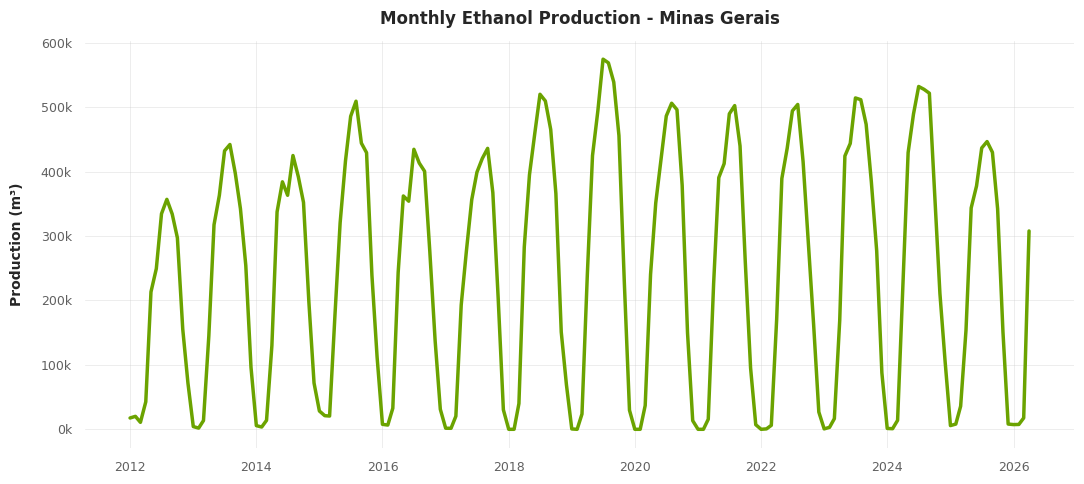

In [82]:
# ------------------------------------------------------------
# Time Series Visualization
# ------------------------------------------------------------

# Plotting
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(x=serie.index, y=serie.values, ax=ax, linewidth=2.5, color="#6BA300")

## Title
ax.set_title(f"Monthly Ethanol Production - Minas Gerais", **title_style)

## Axes Labels
ax.set_xlabel("")
ax.set_ylabel("Production (m³)", **label_style)

## Axes ticks
ax.tick_params(axis='both', which="both", **tick_style)

## Y axis formatter
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

## Hide unnecessary edges
for spine in ax.spines.values():
    spine.set_visible(False)

## Grid
ax.grid( True, which="major", **grid_style)

plt.tight_layout()
plt.show()

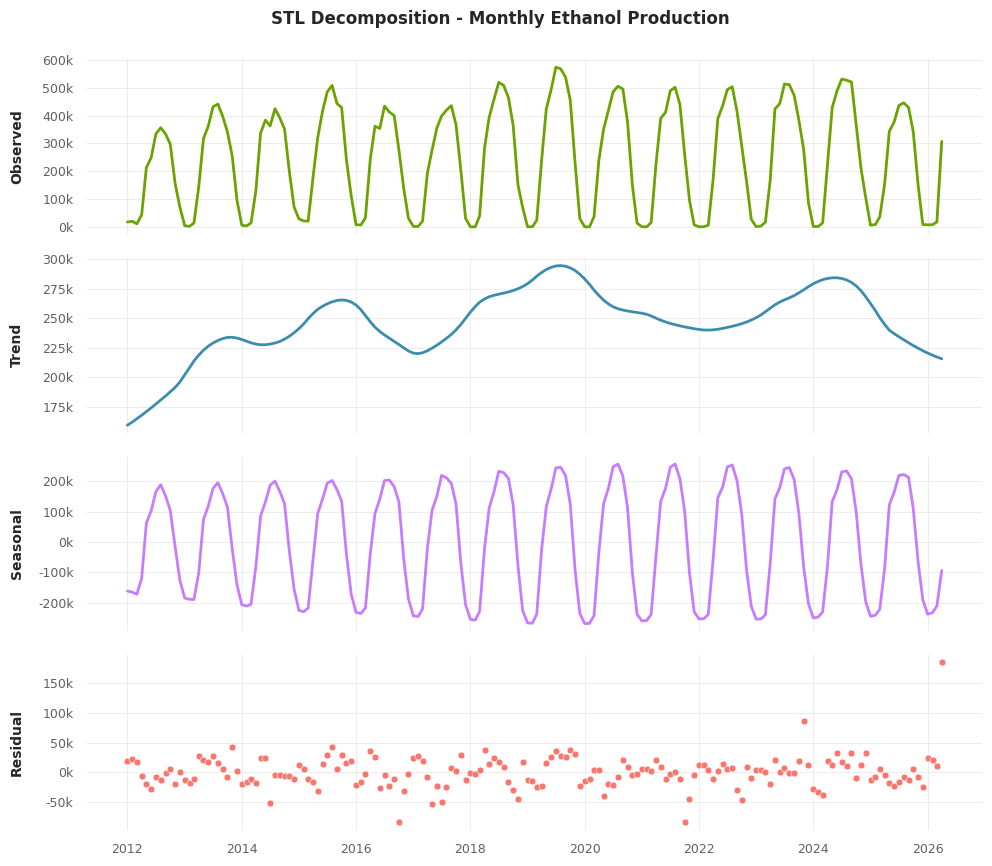

In [85]:
# ------------------------------------------------------------
# Time Series Decomposition
# ------------------------------------------------------------
stl = STL(serie, period=12, robust=True)
res = stl.fit()

# Plotting decomposition
observed = serie
trend = res.trend
seasonal = res.seasonal
residual = res.resid

fig, axes = plt.subplots(4, 1,figsize=(10, 9),sharex=True)

component_data = [
    (observed, "Observed", "#6BA300"),
    (trend, "Trend", "#3C8DAD"),
    (seasonal, "Seasonal", "#C77CFF"),
    (residual, "Residual", "#F8766D")
]

for ax, (series, label, color) in zip(axes, component_data):

    if label == "Residual":
      sns.scatterplot(x=series.index, y=series.values, ax=ax, color=color, s=24)
    else:
      sns.lineplot(x=series.index, y=series.values, ax=ax, linewidth=2.0, color=color)

    fig.suptitle(f"STL Decomposition - Monthly Ethanol Production", fontsize=12, fontweight="semibold", y=0.96)

    ax.set_ylabel(label, **label_style)
    ax.yaxis.set_label_coords(-0.07, 0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

    ax.grid(True, which="major", **grid_style)

    ax.tick_params(axis='both', which="both", **tick_style)

    for spine in ax.spines.values():
          spine.set_visible(False)

## Hide X axis label in upper panels
for ax in axes[:-1]:
    ax.set_xlabel("")

axes[-1].set_xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## ♻ Seasonal Behavior

Lorem Ipsum

In [115]:
# Seasonal serie (Complete)
seasonal_df = serie.to_frame(name="Production")
seasonal_df["Month"] = seasonal_df.index.month
seasonal_df["Year"] = seasonal_df.index.year

# Seasonal serie (Last X available years)
last_n_years = 7
recent_years = sorted(seasonal_df["Year"].unique())[-last_n_years:]
recent_seasonal_df = seasonal_df[seasonal_df["Year"].isin(recent_years)].copy()

# Labels for monthly charts
month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

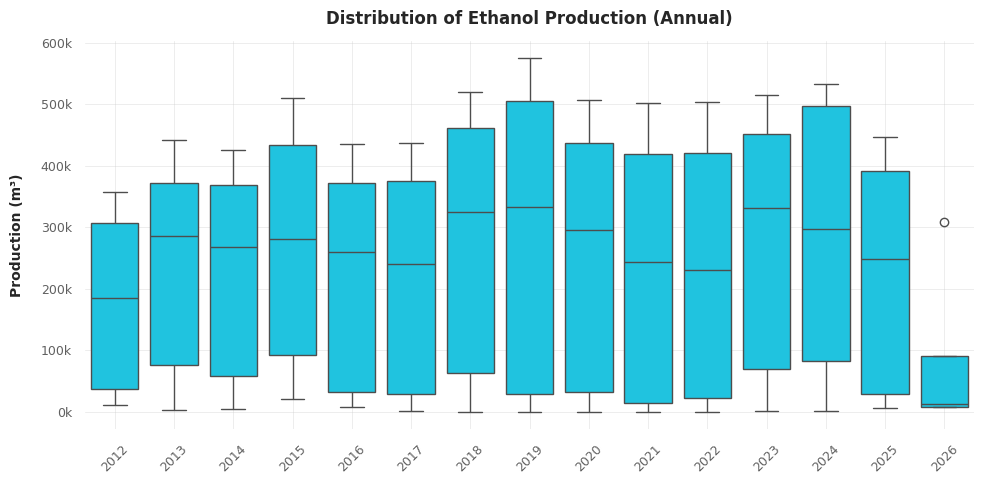

In [86]:
# ------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=seasonal_df, x="Year", y="Production", ax=ax, color="#00D9FF")

ax.set_title(f"Distribution of Ethanol Production (Annual)", **title_style)

ax.set_xlabel("")
ax.set_ylabel("Production (m³)", **label_style)

ax.tick_params(axis="x", which="both", **tick_style, rotation=45)
ax.tick_params(axis="y", which="both", **tick_style)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

for spine in ax.spines.values():
      spine.set_visible(False)

ax.grid(True, which="major", **grid_style)

plt.tight_layout()
plt.show()

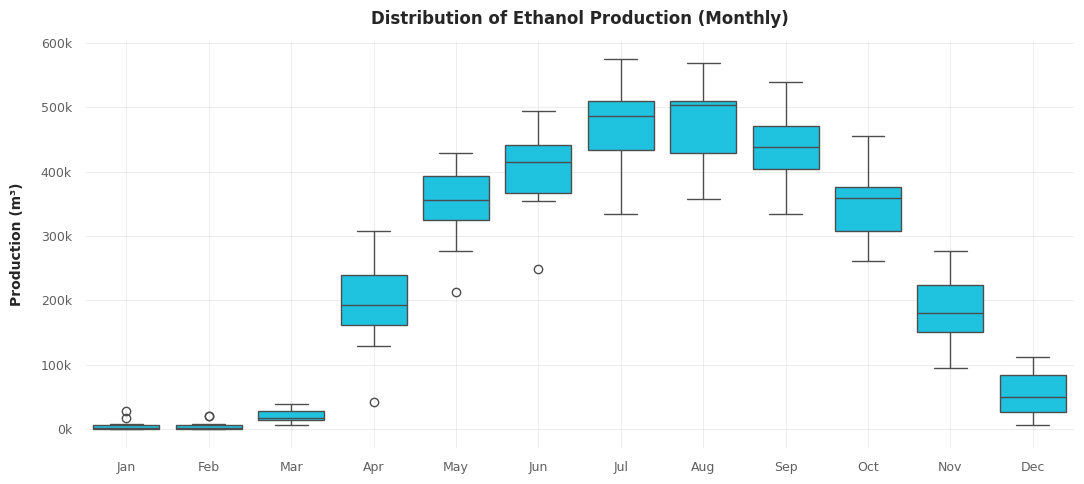

In [90]:
# ------------------------------------------------------------
# Monthly Boxplot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(data=seasonal_df, x="Month", y="Production", ax=ax, color="#00D9FF")

ax.set_title(f"Distribution of Ethanol Production (Monthly)", **title_style)

ax.set_xlabel("", **label_style)
ax.set_ylabel("Production (m³)", **label_style)

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)

ax.tick_params(axis='both', which="both", **tick_style)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

for spine in ax.spines.values():
      spine.set_visible(False)

ax.grid(True, which="major", **grid_style)

plt.tight_layout()
plt.show()

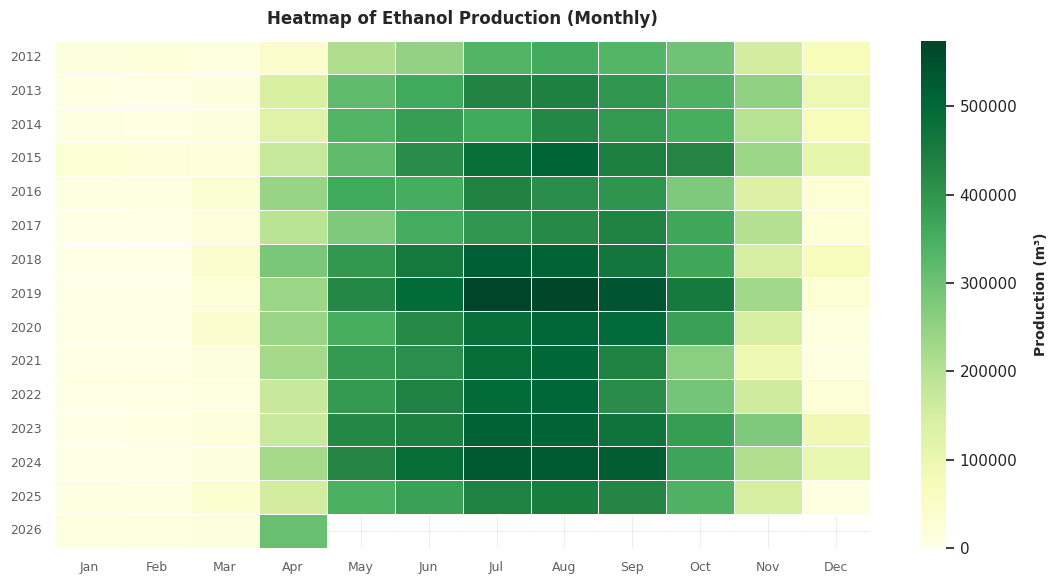

In [108]:
# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

heatmap_data = seasonal_df.pivot_table(index="Year", columns="Month", values="Production")

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(heatmap_data, cmap="YlGn", linewidths=0.5, linecolor="white", cbar_kws={"label": "Production (m³)"},ax=ax)
cbar = ax.figure.axes[-1]
cbar.set_ylabel("Production (m³)", **label_style)

ax.set_title(f"Heatmap of Ethanol Production (Monthly)", **title_style)

ax.set_xlabel("", **label_style)
ax.set_ylabel("", **label_style)

ax.set_xticklabels(month_labels, rotation=0)

ax.tick_params(axis='both', which="both", **tick_style)

ax.grid(True, which="major", **grid_style)

plt.tight_layout()
plt.show()

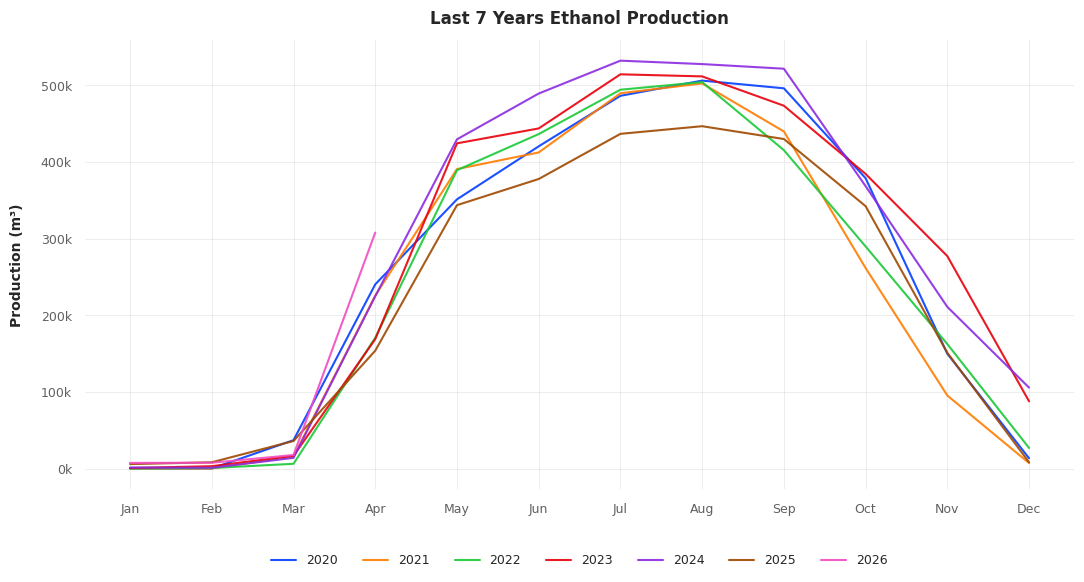

In [127]:
# ------------------------------------------------------------
# Seasonal subseries plot (Last 7 years)
# ------------------------------------------------------------

years = sorted(seasonal_df["Year"].unique())
palette = sns.color_palette("bright", n_colors=len(years))

fig, ax = plt.subplots(figsize=(11, 6))

for color, (year, group) in zip(palette, recent_seasonal_df.groupby("Year")):
    sns.lineplot(x=group["Month"], y=group["Production"], ax=ax, linewidth=1.5, alpha=0.9, label=year, color=color)

ax.set_title(f"Last {last_n_years} Years Ethanol Production", **title_style)

ax.set_xlabel("", **label_style)
ax.set_ylabel("Production (m³)", **label_style)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)

ax.tick_params(axis='both', which="both", **tick_style)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

for spine in ax.spines.values():
      spine.set_visible(False)

ax.grid(True, which="major", **grid_style)

ax.legend(bbox_to_anchor=(0.5, -0.12), loc="upper center", ncol=last_n_years, frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

### Seasonal Behavior Analysis

Lorem Ipsum

## 📈 Stationarity Analysis

Lorem ipsum

In [122]:
# ------------------------------------------------------------
# Augmented Dickey-Fuller Test
# ------------------------------------------------------------
adf_result = adfuller(serie.dropna())

adf_output = pd.Series(
    {
        "ADF statistic": adf_result[0],
        "p-value": adf_result[1],
        "Number of lags used": adf_result[2],
        "Number of observations": adf_result[3],
        "Critical value 1%": adf_result[4]["1%"],
        "Critical value 5%": adf_result[4]["5%"],
        "Critical value 10%": adf_result[4]["10%"]
    }
)

adf_output

,0
ADF statistic,-3.327801
p-value,0.013681
Number of lags used,12.000000
Number of observations,159.000000
Critical value 1%,-3.472161
Critical value 5%,-2.879895
Critical value 10%,-2.576557


In [118]:
alpha = 0.05

if adf_result[1] <= alpha:
    print("Reject H0: the series is likely stationary according to the ADF test.")
else:
    print("Fail to reject H0: the series is likely non-stationary according to the ADF test.")

Reject H0: the series is likely stationary according to the ADF test.


In [123]:
# ------------------------------------------------------------
# KPSS test
# ------------------------------------------------------------

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpss_result = kpss(
        serie.dropna(),
        regression="c",
        nlags="auto"
    )

kpss_output = pd.Series(
    {
        "KPSS statistic": kpss_result[0],
        "p-value": kpss_result[1],
        "Number of lags used": kpss_result[2],
        "Critical value 10%": kpss_result[3]["10%"],
        "Critical value 5%": kpss_result[3]["5%"],
        "Critical value 2.5%": kpss_result[3]["2.5%"],
        "Critical value 1%": kpss_result[3]["1%"]
    }
)

kpss_output

,0
KPSS statistic,0.074627
p-value,0.100000
Number of lags used,6.000000
Critical value 10%,0.347000
Critical value 5%,0.463000
Critical value 2.5%,0.574000
Critical value 1%,0.739000


In [124]:
alpha = 0.05

if kpss_result[1] <= alpha:
    print("Reject H0: the series is likely non-stationary according to the KPSS test.")
else:
    print("Fail to reject H0: the series is likely stationary according to the KPSS test.")

Fail to reject H0: the series is likely stationary according to the KPSS test.


In [ ]:
# Difference (if necessary)
# seasonal_diff = state_series.diff()

### Preliminary Conclusion on Stationarity

Lorem ipsum

## 🔗 Autocorrelation Analysis

Lorem ipsum

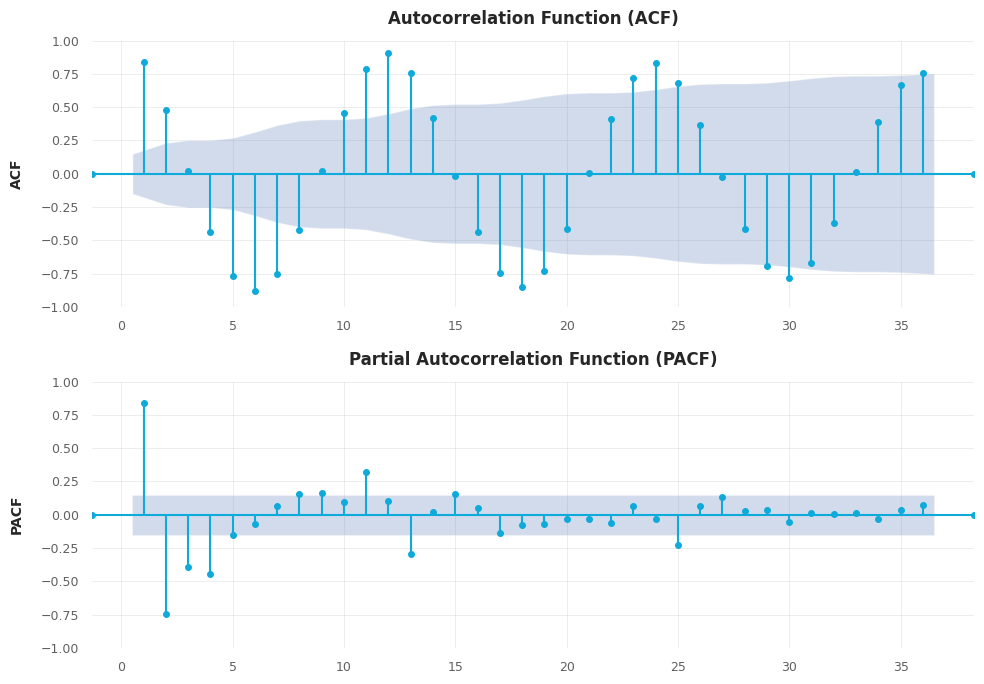

In [129]:
# ------------------------------------------------------------
# Plot ACF and PACF
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

plot_acf(serie, lags=36, ax=axes[0], alpha=0.05, zero=False, title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})
plot_pacf(serie, lags=36, ax=axes[1], alpha=0.05, zero=False, method="ywm", title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})

axes[0].set_title("Autocorrelation Function (ACF)", **title_style)
axes[0].set_ylabel("ACF", **label_style)

axes[1].set_title("Partial Autocorrelation Function (PACF)", **title_style)
axes[1].set_ylabel("PACF", **label_style)

for ax in axes:
    ax.tick_params(axis='both', which="both", **tick_style)

    ax.grid(True, which="major", **grid_style)

    for spine in ax.spines.values():
      spine.set_visible(False)

plt.tight_layout()
plt.show()

### Autocorrelation and Partial Autocorrelation Analysis

Lorem ipsum

# 🧪 Forecasting Experimental Setup

Lorem ipsum

In [ ]:
# ------------------------------------------------------------
# Train-test split
# ------------------------------------------------------------

forecast_horizon = 12

train_series = state_series.iloc[:-forecast_horizon]
test_series = state_series.iloc[-forecast_horizon:]

print(f"Training period: {train_series.index.min().strftime('%Y-%m')} to {train_series.index.max().strftime('%Y-%m')}")
print(f"Testing period: {test_series.index.min().strftime('%Y-%m')} to {test_series.index.max().strftime('%Y-%m')}")
print(f"Training observations: {len(train_series)}")
print(f"Testing observations: {len(test_series)}")

Training period: 2006-09 to 2025-03
Testing period: 2025-04 to 2026-03
Training observations: 223
Testing observations: 12


## 👀 Forecasting Models

Lorem ipsum